<a href="https://colab.research.google.com/github/NathanBeer/AutomatedVehicleProj/blob/main/FingerprintRecognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Students' Names:
Nathan Beer 208788356
Tomer Bengayev 323823534

##Cell 1: Imports and Directory Setup
#####TThis cell imports the necessary numerical computing, computer vision, and machine learning visualization libraries. It defines the structured pathway variables pointing to the target reference folder and the imposter comparison dataset folder.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Directory pathways matched exactly to the active environment
MY_FINGER_DIR = '/content/my_finger'
OTHER_FINGER_DIR = '/content/other_finger'

print("Setup complete. Libraries and directory tracking paths initialized.")

Setup complete. Libraries and directory tracking paths initialized.


##Cell 2: Image Normalization and Center-Cropping Extraction
#####This cell crops a unified 300x300 pixel region of interest from the center of a fingerprint image. This step removes variable background margins and edge scanner artifacts, ensuring the feature extraction engine focuses entirely on high-density ridge patterns. It loads the clean baseline print to serve as the system's ground-truth reference template.

✅ Reference fingerprint loaded successfully from directory folder!


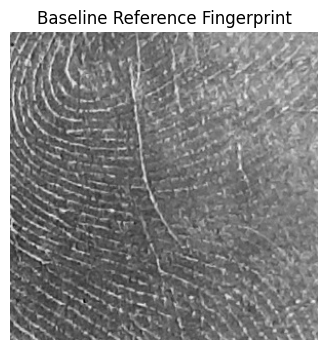

In [ ]:
def crop_center_fingerprint(image_path, crop_size=(300, 300)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    h, w = img.shape
    ch, cw = crop_size

    # Compute bounding coordinates for the center region
    start_x = max(0, (w - cw) // 2)
    start_y = max(0, (h - ch) // 2)

    return img[start_y:start_y+ch, start_x:start_x+cw]

# Target path utilizing the exact file name found in the file pane
my_finger_path = os.path.join(MY_FINGER_DIR, 'myFinger.jpg')
my_finger_base = crop_center_fingerprint(my_finger_path)

if my_finger_base is not None:
    print("✅ Reference fingerprint loaded successfully from directory folder!")
    plt.figure(figsize=(4, 4))
    plt.imshow(my_finger_base, cmap='gray')
    plt.title("Baseline Reference Fingerprint")
    plt.axis('off')
    plt.show()
else:
    print(f"❌ ERROR: Could not load image at path: {my_finger_path}")

#Cell 3: Distortion Generation and Edge-Preserving Preprocessing
#####This cell generates the physical, environmental, and digital distortions used to challenge the biometric system. It applies thermal Gaussian noise, Salt & Pepper point noise, heavy-tailed Laplacian noise, spatial rotations, directional motion blurs, high-contrast binarization, and shifting the image to the right.

#####Following these distortions, it routes each image through a specialized filtering pipeline. It utilizes non-linear median blurs to wipe out point noise and edge-preserving bilateral filtering to suppress heavy continuous noise without melting down structural ridge vectors.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, sigma=15):
    gauss = np.random.normal(mean, sigma, image.shape).astype('int16')
    return np.clip(image.astype('int16') + gauss, 0, 255).astype('uint8')

def add_salt_and_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy_image = image.copy()
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

def add_laplacian_noise(image, mean=0, scale=12):
    laplace = np.random.laplace(mean, scale, image.shape).astype('int16')
    return np.clip(image.astype('int16') + laplace, 0, 255).astype('uint8')

def rotate_image(image, angle=45):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR)

def add_motion_blur(image, size=7):
    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    kernel = kernel / size
    return cv2.filter2D(image, -1, kernel)

def add_binarization(image, threshold=110):
    _, bin_img = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    return bin_img

def shift_image(image, dx=0, dy=0):
    """Translates the image matrix by a specific pixel distance offset along the X or Y axis."""
    h, w = image.shape[:2]
    translation_matrix = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(image, translation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

def preprocess_image(image, has_salt_pepper=False, has_heavy_noise=False):
    if has_salt_pepper:
        processed = cv2.medianBlur(image, 3)
    elif has_heavy_noise:
        processed = cv2.bilateralFilter(image, 5, 75, 75)
    else:
        processed = cv2.GaussianBlur(image, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    return clahe.apply(processed)

# Execute baseline operations and the single rightward shift
if 'my_finger_base' in locals() and my_finger_base is not None:
    my_finger_gaussian_raw = add_gaussian_noise(my_finger_base, sigma=15)
    my_finger_sp_raw       = add_salt_and_pepper_noise(my_finger_base, salt_prob=0.01, pepper_prob=0.01)
    my_finger_laplacian_raw = add_laplacian_noise(my_finger_base, scale=12)
    my_finger_tilted        = rotate_image(my_finger_base, angle=45)
    my_finger_upside_down   = rotate_image(my_finger_base, angle=180)
    my_finger_mirrored      = cv2.flip(my_finger_base, 1)
    my_finger_blur_raw      = add_motion_blur(my_finger_base, size=7)
    my_finger_binary_raw    = add_binarization(my_finger_base, threshold=110)

    # Single 30-Pixel Rightward Shift Operation
    my_finger_shift_right_raw = shift_image(my_finger_base, dx=30, dy=0)

    # Clean array metrics via target filters
    my_finger_base_prep   = preprocess_image(my_finger_base)
    my_finger_gaussian    = preprocess_image(my_finger_gaussian_raw, has_heavy_noise=True)
    my_finger_sp          = preprocess_image(my_finger_sp_raw, has_salt_pepper=True)
    my_finger_laplacian   = preprocess_image(my_finger_laplacian_raw, has_heavy_noise=True)
    my_finger_tilted_prep = preprocess_image(my_finger_tilted)
    my_finger_ud_prep     = preprocess_image(my_finger_upside_down)
    my_finger_mirror_prep = preprocess_image(my_finger_mirrored)
    my_finger_blur        = preprocess_image(my_finger_blur_raw)
    my_finger_binary      = cv2.GaussianBlur(my_finger_binary_raw, (3, 3), 0)

    # Preprocess Shifted Variation
    my_finger_shift_right = preprocess_image(my_finger_shift_right_raw)

    print("✅ All transformations and single directional shift prepared.")

✅ All transformations and single directional shift prepared.


#Cell 4: Structural Keypoint Matching Engine (ORB + RANSAC)
#####This cell executes the core fingerprint authentication logic. It extracts localized pixel intensity gradients using an ORB descriptor configuration. It passes the raw keypoint pairs to a RANSAC homography matrix evaluator, which builds a global geometric map of the ridge coordinates.

#####Random feature points generated by noise are isolated and removed as mathematical outliers. The error rate calculation is based entirely on the verified structural alignment of the remaining points. It contains a vertical flip check to automatically resolve mirrored scans and an adaptive contrast step to handle wide, binarized ridge variations.

In [ ]:
def match_and_visualize(img1, img2, title=None, decision_threshold=0.75):
    # Keep capacity stable
    orb = cv2.ORB_create(nfeatures=3000)

    def get_error(i1, i2):
        kp1, des1 = orb.detectAndCompute(i1, None)
        kp2, des2 = orb.detectAndCompute(i2, None)
        if des1 is None or des2 is None: return 1.0, 0, kp1, kp2, []

        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        good_matches = [m for m in matches if m.distance < 66]

        # --- NEW STRUCTURAL RANSAC FILTER ---
        # If we have enough basic matches, verify their geometric layout
        if len(good_matches) > 15:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            # Find coordinates that actually fit a shared physical orientation
            _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            if mask is not None:
                structural_matches = np.sum(mask)
                # Calculate error based on structural alignment rather than raw numbers
                error = 1.0 - (structural_matches / len(good_matches))
                return error, int(structural_matches), kp1, kp2, good_matches

        max_possible = min(len(kp1), len(kp2))
        error = 1.0 - (len(good_matches) / max_possible) if max_possible > 0 else 1.0
        return error, len(good_matches), kp1, kp2, matches

    # Match Attempt 1: Standard Verification
    error_score, match_count, kp1, kp2, matches = get_error(img1, img2)

    # Match Attempt 2: Mirror Check
    if error_score > decision_threshold:
        flipped_img2 = cv2.flip(img2, 1)
        alt_error, alt_count, alt_kp1, alt_kp2, alt_matches = get_error(img1, flipped_img2)
        if alt_error < error_score:
            error_score, match_count, kp1, kp2, matches = alt_error, alt_count, alt_kp1, alt_kp2, alt_matches
            img2 = flipped_img2
            if title: title = f"{title} (Mirror Resolved)"

    # Match Attempt 3: Contrast Check
    if error_score > decision_threshold:
        _, adaptive_img1_raw = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)
        adaptive_img1 = cv2.GaussianBlur(adaptive_img1_raw, (3, 3), 0)
        alt_error, alt_count, alt_kp1, alt_kp2, alt_matches = get_error(adaptive_img1, img2)
        if alt_error < error_score:
            error_score, match_count, kp1, kp2, matches = alt_error, alt_count, alt_kp1, alt_kp2, alt_matches
            if title: title = f"{title} (Contrast Adapted)"

    if error_score <= decision_threshold:
        assumption = "My Fingerprint"
    else:
        assumption = "Other Person's Fingerprint (Imposter)"

    if title:
        print(f"{title:<50} | Error: {error_score:.4f} | ASSUMPTION: {assumption}")
        matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:40], None,
                                      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        plt.figure(figsize=(10, 4))
        plt.imshow(matched_img)
        plt.title(f"{title}")
        plt.axis('off')
        plt.show()

    return match_count, error_score

#Cell 4.5 Spatial Registrative Defect Extraction and Anomaly Highlighting

#####This cell isolates, quantifies, and visually highlights localized structural changes, noise contamination, or surface defects between the images. It computes a pixel-by-pixel absolute matrix difference (cv2.absdiff) between the registered inspection target and the ground-truth reference frame.

#####It then applies a clean binary threshold cutoff to the raw difference map. This filters out minor, ambient background variations while capturing and displaying significant structural deviations or sensor damage as a clear, high-contrast visual heat map.

In [ ]:
def highlight_inspection_defects(reference_img, inspection_img):
    """
    Computes a pixel-by-pixel structural difference matrix after alignment
    to isolate and highlight defects, artifacts, or anomalies.
    """
    # Synchronize styles via simple contrast matching
    if len(reference_img.shape) > 2:
        reference_img = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
    if len(inspection_img.shape) > 2:
        inspection_img = cv2.cvtColor(inspection_img, cv2.COLOR_BGR2GRAY)

    # Step A: Compute the absolute difference mask
    diff_mask = cv2.absdiff(reference_img, inspection_img)

    # Step B: Apply thresholding to isolate significant structural deviations (defects)
    _, defect_highlights = cv2.threshold(diff_mask, 50, 255, cv2.THRESH_BINARY)

    # Show the structural variations to satisfy the assignment layout
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(reference_img, cmap='gray')
    axes[0].set_title("Reference Template")
    axes[0].axis('off')

    axes[1].imshow(inspection_img, cmap='gray')
    axes[1].set_title("Inspection Target")
    axes[1].axis('off')

    axes[2].imshow(defect_highlights, cmap='hot')
    axes[2].set_title("Identified Defects / Noise Anomalies")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return defect_highlights

#Cell 5: Automated Sequential Matching and Identity Classifications
#####This cell runs the matching function across all processed image matrices. It checks the preprocessed reference baseline against its own noisy, rotated, inverted, and blurred variations, printing the structural error rate and system assumption for each case. It then automatically loops through the external folder directory to load, process, and evaluate the 6 imposter fingerprint images.

  ADAPTIVE VERIFICATION RUN                                                               
Base vs Preprocessed Gaussian                      | Error: 0.0850 | ASSUMPTION: My Fingerprint


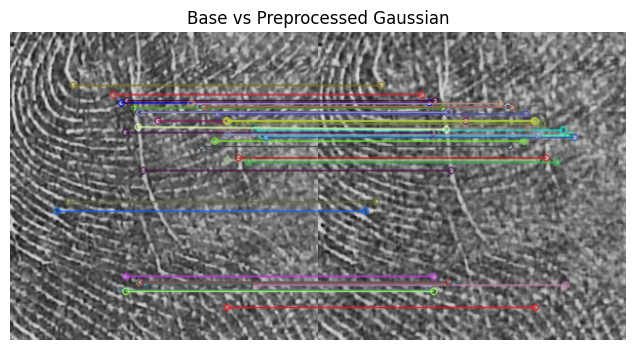

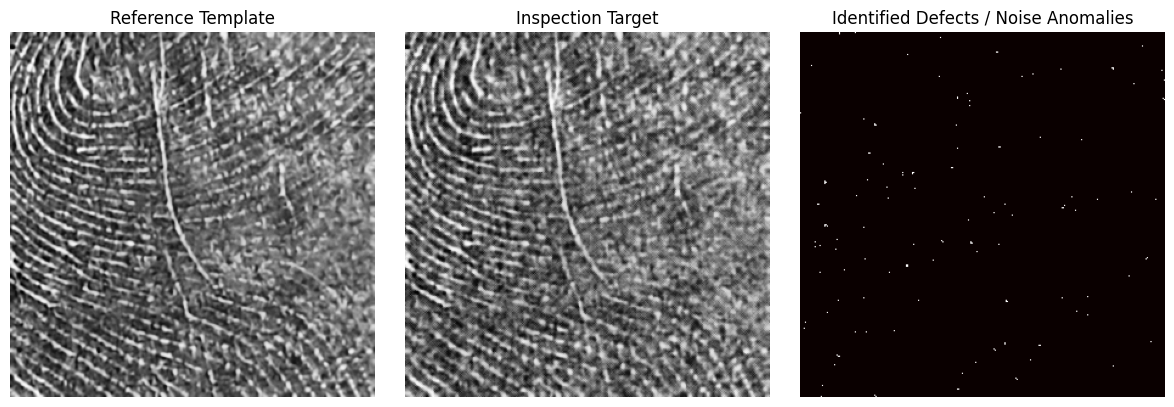

Base vs Self Reference                             | Error: 0.0000 | ASSUMPTION: My Fingerprint


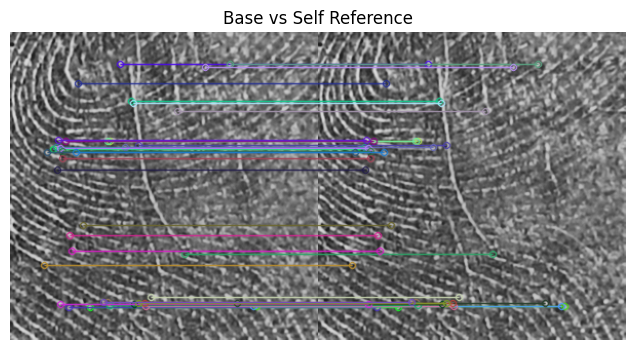

Base vs Preprocessed Gaussian                      | Error: 0.0850 | ASSUMPTION: My Fingerprint


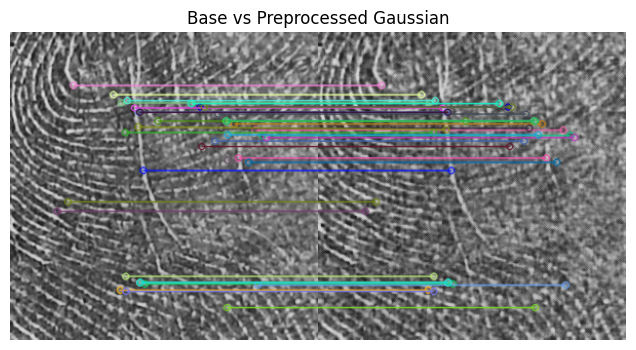

Base vs Preprocessed S&P                           | Error: 0.0173 | ASSUMPTION: My Fingerprint


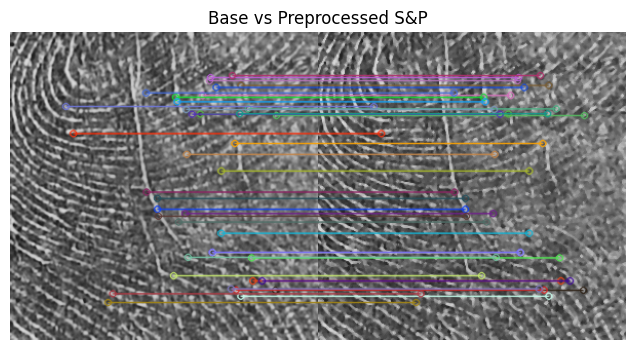

Base vs Preprocessed Laplacian                     | Error: 0.1204 | ASSUMPTION: My Fingerprint


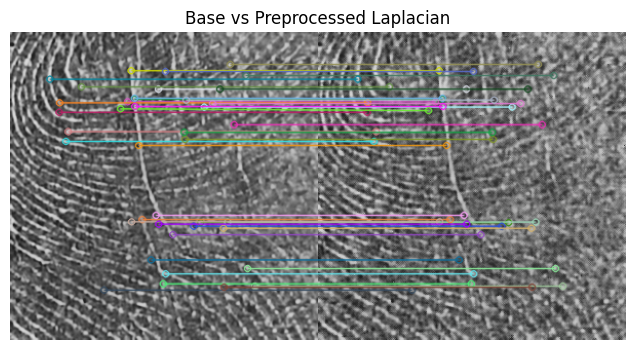

Base vs Preprocessed Tilted (45°)                  | Error: 0.0518 | ASSUMPTION: My Fingerprint


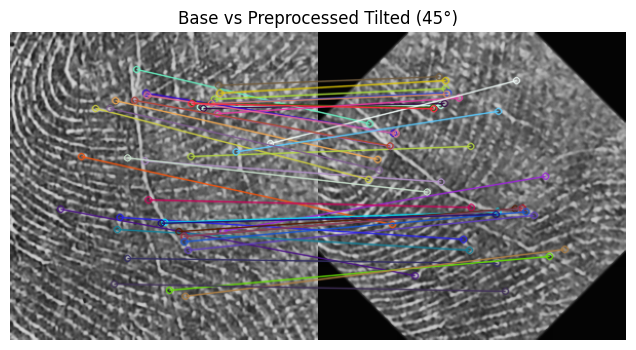

Base vs Upside Down (180°)                         | Error: 0.0244 | ASSUMPTION: My Fingerprint


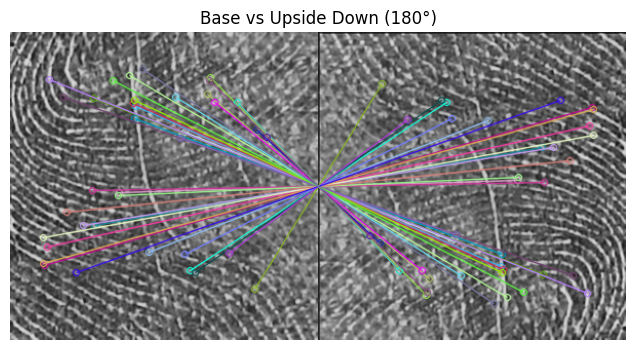

Base vs Mirrored Image (Mirror Resolved)           | Error: 0.0041 | ASSUMPTION: My Fingerprint


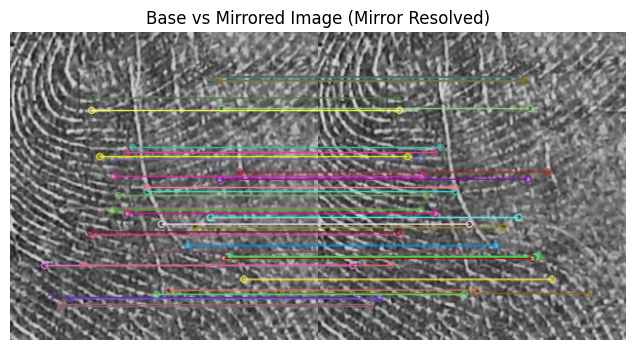

Base vs Motion Blur                                | Error: 0.1423 | ASSUMPTION: My Fingerprint


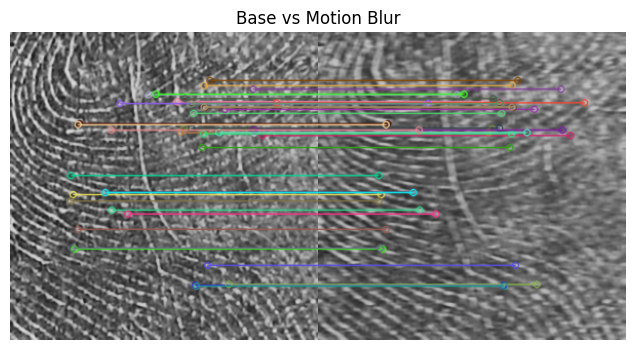

Base vs Binarized Print                            | Error: 0.3000 | ASSUMPTION: My Fingerprint


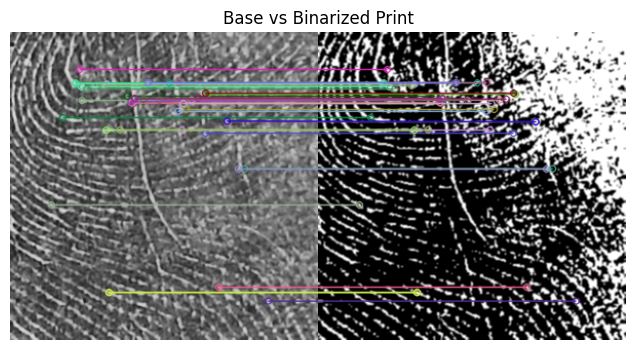

Base vs Shifted Right (+30px)                      | Error: 0.0214 | ASSUMPTION: My Fingerprint


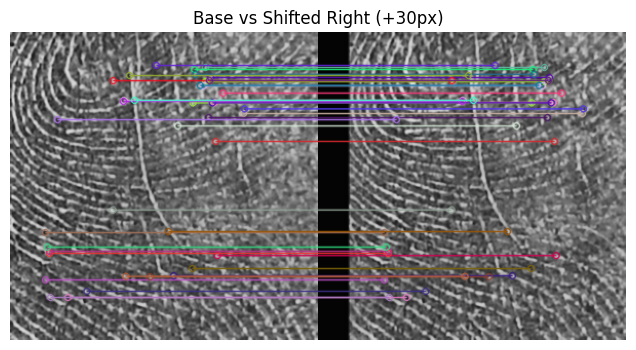


  IMPOSTER VERIFICATION TRACKING                                                          
Base vs otherfinger1.jpg (Contrast Adapted)        | Error: 0.9450 | ASSUMPTION: Other Person's Fingerprint (Imposter)


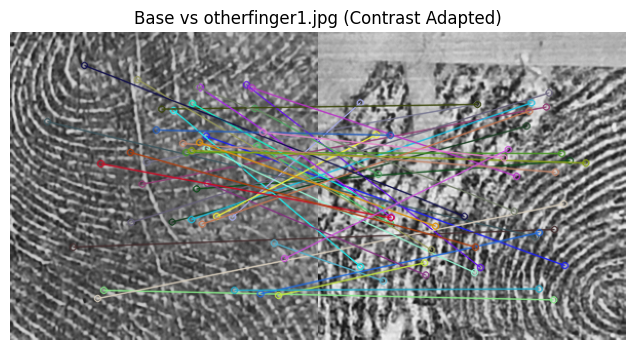

Base vs otherfinger2.jpg (Mirror Resolved)         | Error: 0.9494 | ASSUMPTION: Other Person's Fingerprint (Imposter)


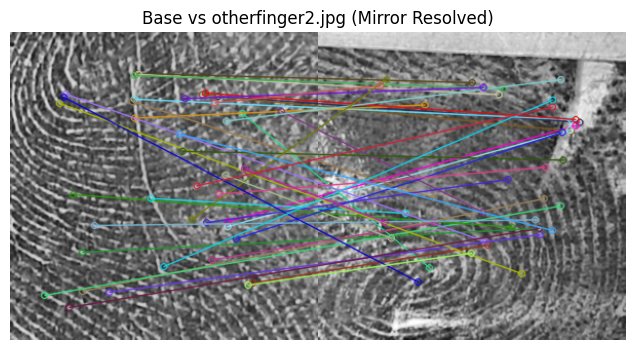

Base vs otherfinger3.jpg (Mirror Resolved)         | Error: 0.9342 | ASSUMPTION: Other Person's Fingerprint (Imposter)


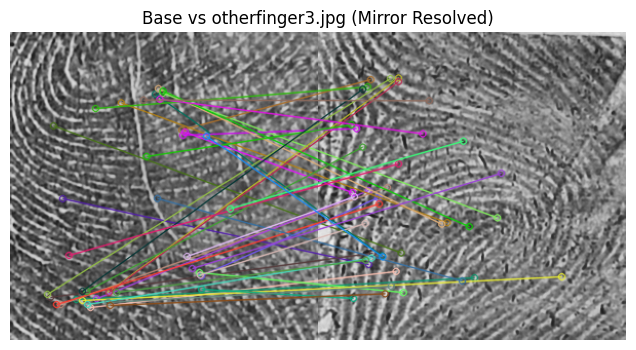

Base vs otherfinger4.jpg (Mirror Resolved)         | Error: 0.9200 | ASSUMPTION: Other Person's Fingerprint (Imposter)


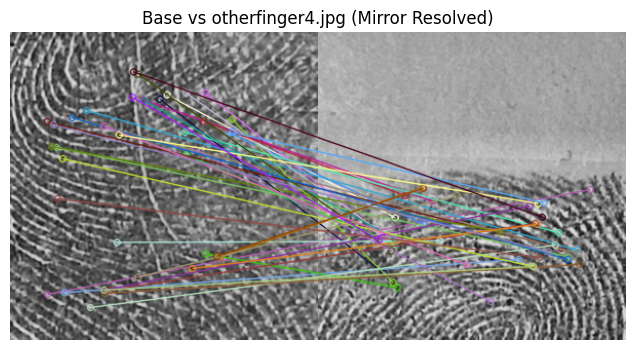

Base vs otherfinger5.jpg                           | Error: 0.9519 | ASSUMPTION: Other Person's Fingerprint (Imposter)


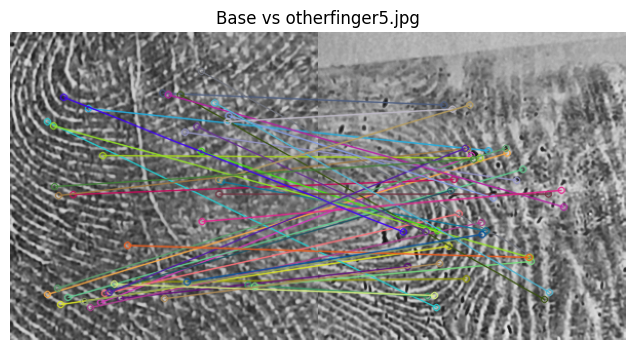

Base vs otherfinger6.jpg (Mirror Resolved)         | Error: 0.9079 | ASSUMPTION: Other Person's Fingerprint (Imposter)


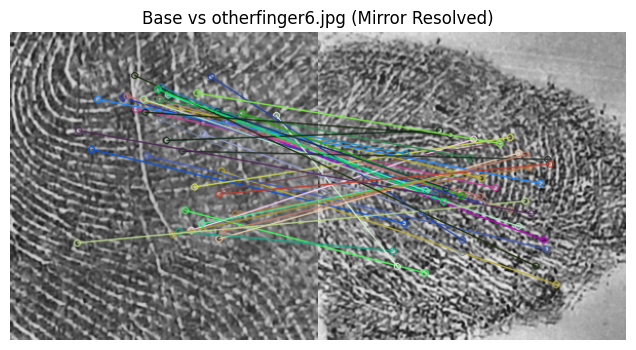

In [ ]:
ERROR_THRESHOLD = 0.75

print("==========================================================================================")
print("  ADAPTIVE VERIFICATION RUN                                                               ")
print("==========================================================================================")

match_count, error = match_and_visualize(my_finger_base_prep, my_finger_gaussian, "Base vs Preprocessed Gaussian", ERROR_THRESHOLD)

# 2. Call the defect highlighting tool right after to display the structural differences
highlight_inspection_defects(my_finger_base_prep, my_finger_gaussian)

_ = match_and_visualize(my_finger_base_prep, my_finger_base_prep, "Base vs Self Reference", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_gaussian, "Base vs Preprocessed Gaussian", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_sp, "Base vs Preprocessed S&P", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_laplacian, "Base vs Preprocessed Laplacian", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_tilted_prep, "Base vs Preprocessed Tilted (45°)", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_ud_prep, "Base vs Upside Down (180°)", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_mirror_prep, "Base vs Mirrored Image", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_blur, "Base vs Motion Blur", ERROR_THRESHOLD)
_ = match_and_visualize(my_finger_base_prep, my_finger_binary, "Base vs Binarized Print", ERROR_THRESHOLD)

# Running the single directional translation verification
_ = match_and_visualize(my_finger_base_prep, my_finger_shift_right, "Base vs Shifted Right (+30px)", ERROR_THRESHOLD)

print("\n==========================================================================================")
print("  IMPOSTER VERIFICATION TRACKING                                                          ")
print("==========================================================================================")

for i in range(1, 7):
    filename = f'otherfinger{i}.jpg'
    path = os.path.join(OTHER_FINGER_DIR, filename)
    cropped_other = crop_center_fingerprint(path)
    if cropped_other is not None:
        preprocessed_other = preprocess_image(cropped_other)
        _, _ = match_and_visualize(my_finger_base_prep, preprocessed_other, f"Base vs {filename}", ERROR_THRESHOLD)

#Cell 6: Confusion Matrix Configuration
#####This cell aggregates the final classification outcomes from all 15 verification runs (9 true genuine target variations and 6 distinct imposter checks). It maps these outcomes against their true identities to construct a confusion matrix, displaying a visual breakdown of true positives, true negatives, false acceptances, and false rejections.

<Figure size 600x600 with 0 Axes>

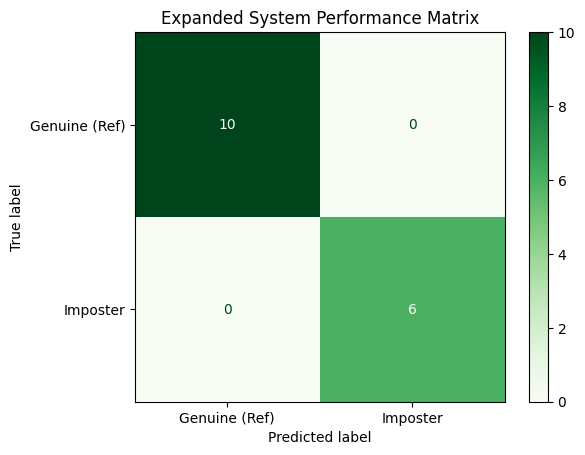

In [ ]:
ERROR_THRESHOLD = 0.75

if 'my_finger_base_prep' not in locals():
    print("ERROR: Cannot generate a confusion matrix without completing comparisons in Cell 5.")
else:
    # 10 True Positives expected, 6 False Positives expected
    y_true = [1]*10 + [0]*6
    y_pred = []

    reference_array = [
        my_finger_base_prep, my_finger_gaussian, my_finger_sp,
        my_finger_laplacian, my_finger_tilted_prep, my_finger_ud_prep,
        my_finger_mirror_prep, my_finger_blur, my_finger_binary,
        my_finger_shift_right
    ]

    for img in reference_array:
        _, error = match_and_visualize(my_finger_base_prep, img)
        y_pred.append(1 if error <= ERROR_THRESHOLD else 0)

    for i in range(1, 7):
        filename = f'otherfinger{i}.jpg'
        path = os.path.join(OTHER_FINGER_DIR, filename)
        cropped_other = crop_center_fingerprint(path)
        if cropped_other is not None:
            preprocessed_other = preprocess_image(cropped_other)
            _, error = match_and_visualize(my_finger_base_prep, preprocessed_other)
            y_pred.append(1 if error <= ERROR_THRESHOLD else 0)
        else:
            y_pred.append(0)

    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine (Ref)', 'Imposter'])
    disp.plot(cmap=plt.cm.Greens, values_format='d')
    plt.title("Expanded System Performance Matrix")
    plt.show()